# Persisted Patient-Level Split

Audits the fixed 70/15/15 split stratified by UT-D1, UT-D2, and MOGaMBO. Every slice from one patient must stay in exactly one split.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
import yaml

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
with (REPO_ROOT / 'configs/config.yaml').open(encoding='utf-8') as file:
    config = yaml.safe_load(file)

from src.data.loader import VALID_SPLITS, assert_disjoint_patients, load_manifest
split_df = pd.read_csv(REPO_ROOT / config['data']['patient_splits_file'])
manifest = load_manifest(REPO_ROOT / config['data']['processed_dir'])
print(f'Persisted patient assignments: {len(split_df)}')

Persisted patient assignments: 149


In [2]:
display(pd.crosstab([split_df['split'], split_df['source_site']], split_df['label'], margins=True))
frames = {split: manifest[manifest['split'] == split] for split in VALID_SPLITS}
assert_disjoint_patients(frames)
assert manifest.groupby('patient_id')['split'].nunique().eq(1).all()
assert set(split_df.patient_id) == set(manifest.patient_id)
print('PASS: persisted assignments, manifest, and three-way leakage guard agree.')

label                    0   1  All
split      source_site             
test       MOGaMBO       9   0    9
           UT-D1         0   7    7
           UT-D2         0   7    7
train      MOGaMBO      41   0   41
           UT-D1         0  32   32
           UT-D2         0  31   31
validation MOGaMBO       9   0    9
           UT-D1         0   6    6
           UT-D2         0   7    7
All                     59  90  149

PASS: persisted assignments, manifest, and three-way leakage guard agree.


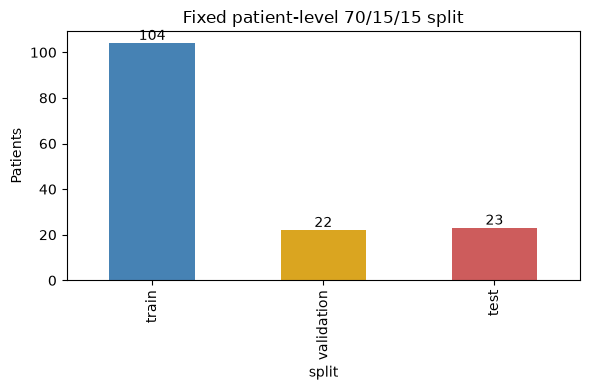

In [3]:
counts = split_df['split'].value_counts().reindex(VALID_SPLITS)
axis = counts.plot.bar(color=['steelblue', 'goldenrod', 'indianred'], figsize=(6, 4))
axis.set_ylabel('Patients')
axis.set_title('Fixed patient-level 70/15/15 split')
for container in axis.containers: axis.bar_label(container)
plt.tight_layout()
plt.show()

The internal test set remains untouched during training and threshold selection. The separate collaborating-hospital cohort remains reserved for external evaluation after labels and T2 series are verified.